# Do Traditional Models Understand Images or Just Pixel Patterns?
#A Study Using One-Class SVM and Image Distortions

## Aim
#This notebook investigates whether a One-Class Support Vector Machine (SVM) relies heavily on pixel-level details when modelling image data.

#We evaluate the model on distorted versions of images:


- Blur
- Noise
- Edge-only

## Dataset
Fashion-MNIST

In [ ]:
# If needed:
# !pip install torch torchvision matplotlib numpy scipy scikit-image

## Import libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from skimage import feature

from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

import torch
from torch.utils.data import Dataset, Subset
from torchvision import datasets, transforms

## Set device

In [ ]:
np.random.seed(42)
torch.manual_seed(42)

## Load Fashion-MNIST

In [ ]:
transform = transforms.ToTensor()

train_full = datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform)
test_full = datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)

# Smaller subset for faster training
train_idx = np.random.choice(len(train_full), 12000, replace=False)
test_idx = np.random.choice(len(test_full), 3000, replace=False)

train_base = Subset(train_full, train_idx)
test_base = Subset(test_full, test_idx)

100%|██████████| 26.4M/26.4M [00:01<00:00, 16.6MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 266kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 4.92MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 17.7MB/s]


## Define class names

In [ ]:
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

## Show sample images

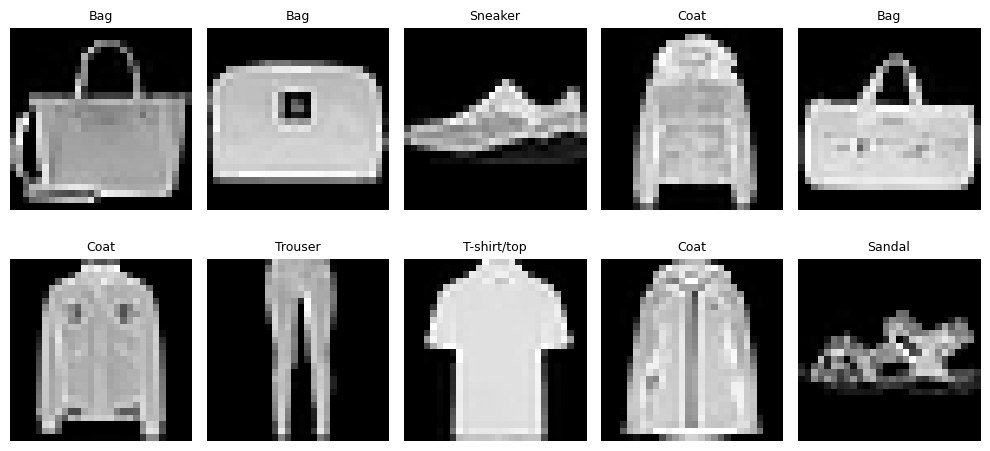

In [15]:
#Visualise Sample Images
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flatten()):
    img, label = train_base[i]
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(class_names[label], fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Define image distortions

In [16]:
def blur_image(img, sigma=1.2):
    arr = img.squeeze().numpy()
    arr = gaussian_filter(arr, sigma=sigma)
    return torch.tensor(arr).unsqueeze(0)

def noise_image(img, std=0.35):
    arr = img.squeeze().numpy()
    noise = np.random.normal(0, std, arr.shape)
    arr = np.clip(arr + noise, 0, 1)
    return torch.tensor(arr).unsqueeze(0)

def edge_image(img, sigma=1.0):
    arr = img.squeeze().numpy()
    arr = feature.canny(arr, sigma=sigma).astype(np.float32)
    return torch.tensor(arr).unsqueeze(0)

## Create distorted dataset wrapper

In [17]:
class DistortedDataset(Dataset):
    def __init__(self, base_dataset, distortion=None):
        self.base = base_dataset
        self.distortion = distortion

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        img, label = self.base[idx]

        if self.distortion == "blur":
            img = blur_image(img)
        elif self.distortion == "noise":
            img = noise_image(img)
        elif self.distortion == "edge":
            img = edge_image(img)

        return img, label

## Create training and test datasets

In [18]:
train_dataset = DistortedDataset(train_base, None)

test_original = DistortedDataset(test_base, None)
test_blur = DistortedDataset(test_base, "blur")
test_noise = DistortedDataset(test_base, "noise")
test_edge = DistortedDataset(test_base, "edge")

## Visualise Distortions

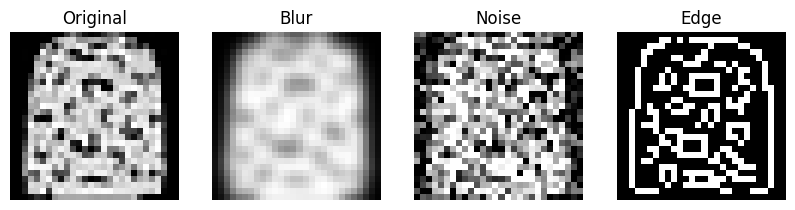

In [19]:
img, label = test_base[0]

imgs = [img, blur_image(img), noise_image(img), edge_image(img)]
titles = ["Original", "Blur", "Noise", "Edge"]

fig, axes = plt.subplots(1, 4, figsize=(10, 3))

for ax, im, t in zip(axes, imgs, titles):
    ax.imshow(im.squeeze(), cmap="gray")
    ax.set_title(t)
    ax.axis("off")

plt.show()

## Flatten Data for SVM

In [20]:
def flatten_dataset(dataset):
    X, y = [], []
    for img, label in dataset:
        X.append(img.view(-1).numpy())
        y.append(label)
    return np.array(X), np.array(y)

##Prepare Data

In [21]:
X_train, y_train = flatten_dataset(train_dataset)
X_test, _ = flatten_dataset(test_original)
X_blur, _ = flatten_dataset(test_blur)
X_noise, _ = flatten_dataset(test_noise)
X_edge, _ = flatten_dataset(test_edge)

## Feature Scaling

In [22]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_blur = scaler.transform(X_blur)
X_noise = scaler.transform(X_noise)
X_edge = scaler.transform(X_edge)

## Train One-Class SVM

In [23]:
model = OneClassSVM(kernel='rbf', gamma=0.01, nu=0.1)
model.fit(X_train)

OneClassSVM(gamma=0.01, nu=0.1)

## Evaluation Function

In [25]:
def evaluate_ocsvm(model, X):
    preds = model.predict(X)
    return np.mean(preds == 1)  # proportion classified as normal

## Evaluate the model

In [26]:
acc_original = evaluate_ocsvm(model, X_test)
acc_blur = evaluate_ocsvm(model, X_blur)
acc_noise = evaluate_ocsvm(model, X_noise)
acc_edge = evaluate_ocsvm(model, X_edge)

print("Original:", acc_original)
print("Blur:", acc_blur)
print("Noise:", acc_noise)
print("Edge:", acc_edge)

Original: 0.48433333333333334
Blur: 0.7323333333333333
Noise: 0.0
Edge: 0.0


## Plot Results

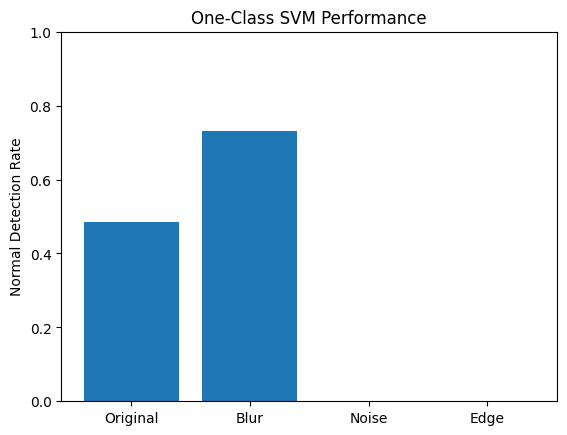

In [27]:
conditions = ["Original", "Blur", "Noise", "Edge"]
accuracies = [acc_original, acc_blur, acc_noise, acc_edge]

plt.bar(conditions, accuracies)
plt.title("One-Class SVM Performance")
plt.ylabel("Normal Detection Rate")
plt.ylim(0,1)
plt.show()

Accuracy Drop

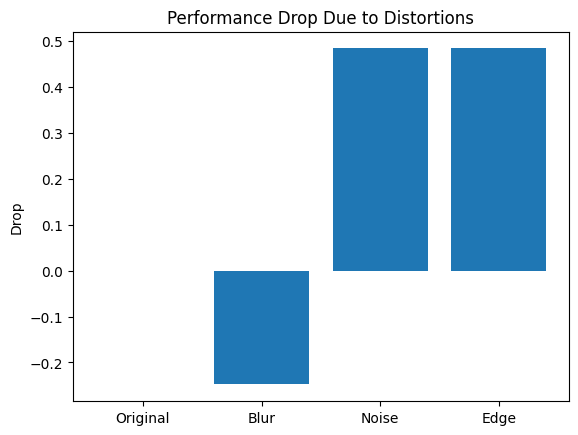

In [28]:
drops = [0,
         acc_original - acc_blur,
         acc_original - acc_noise,
         acc_original - acc_edge]

plt.bar(conditions, drops)
plt.title("Performance Drop Due to Distortions")
plt.ylabel("Drop")
plt.show()

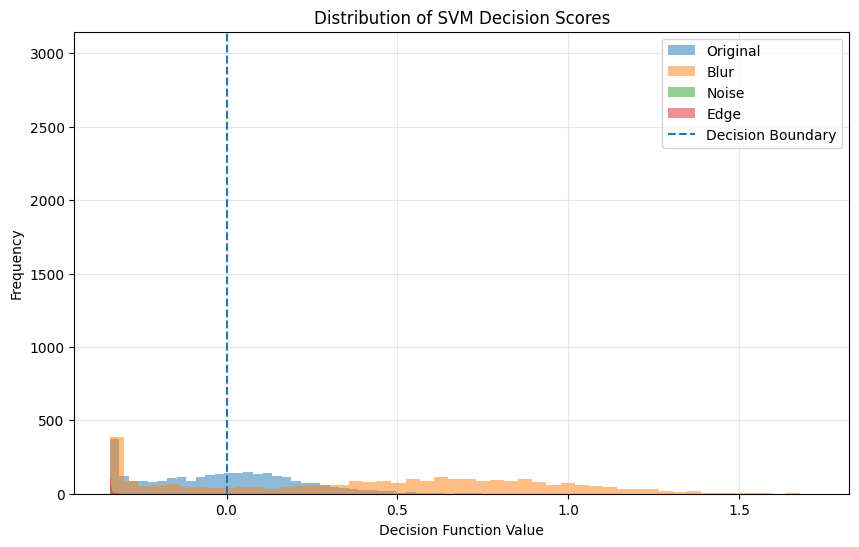

In [32]:
# Get decision scores
scores_original = model.decision_function(X_test)
scores_blur = model.decision_function(X_blur)
scores_noise = model.decision_function(X_noise)
scores_edge = model.decision_function(X_edge)

plt.figure(figsize=(10, 6))

plt.hist(scores_original, bins=50, alpha=0.5, label="Original")
plt.hist(scores_blur, bins=50, alpha=0.5, label="Blur")
plt.hist(scores_noise, bins=50, alpha=0.5, label="Noise")
plt.hist(scores_edge, bins=50, alpha=0.5, label="Edge")

plt.axvline(0, linestyle='--', label="Decision Boundary")

plt.title("Distribution of SVM Decision Scores")
plt.xlabel("Decision Function Value")
plt.ylabel("Frequency")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Confusion Matrix

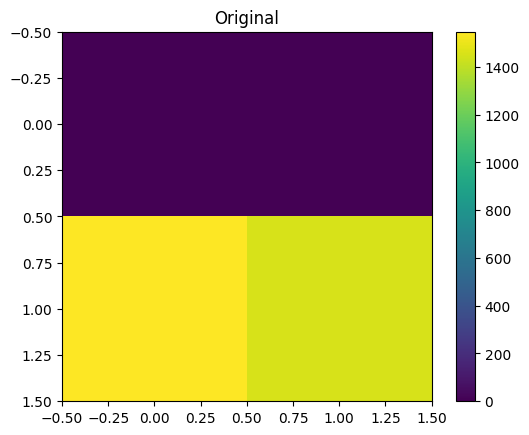

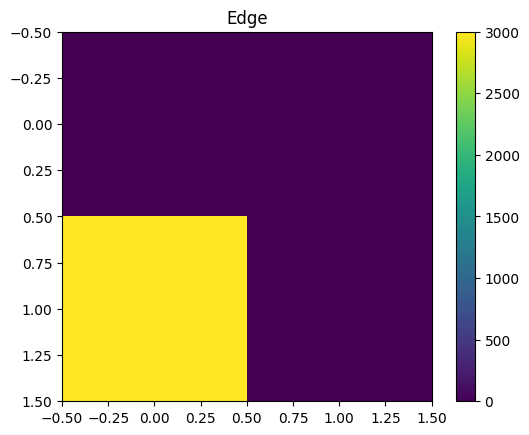

In [30]:
def plot_confusion(X, title):
    preds = model.predict(X)
    true = np.ones(len(preds))  # assume normal

    cm = confusion_matrix(true, preds)

    plt.imshow(cm, cmap="viridis")
    plt.title(title)
    plt.colorbar()
    plt.show()

plot_confusion(X_test, "Original")
plot_confusion(X_edge, "Edge")

## Results Table

In [31]:
import pandas as pd

results = pd.DataFrame({
    "Condition": conditions,
    "Normal Rate": accuracies
})

results

,Condition,Normal Rate
0,Original,0.484333
1,Blur,0.732333
2,Noise,0.000000
3,Edge,0.000000


## Conclusion

The One-Class SVM successfully models the distribution of normal Fashion-MNIST images. When distortions such as blur, noise, and edge extraction are applied, the model increasingly classifies these inputs as anomalies.

This suggests that the model relies heavily on pixel-level structures. Strong drops in performance indicate sensitivity to texture-like features, similar to behaviour observed in deep learning models.

REFERENCES:

Schölkopf, B. et al. (2001) Estimating the support of a high-dimensional distribution. Neural Computation.

Pedregosa, F. et al. (2011) Scikit-learn: Machine learning in Python. JMLR.

Geirhos, R. et al. (2019) CNNs are biased towards texture. ICLR.

Xiao, H. et al. (2017) Fashion-MNIST dataset.

Bishop, C. (2006) Pattern Recognition and Machine Learning. Springer
Schölkopf, B. and Smola, A.J. (2002)
Learning with Kernels: Support Vector Machines, Regularization, Optimization, and Beyond
MIT Press.

Hofmann, T., Schölkopf, B. and Smola, A.J. (2008)
Kernel methods in machine learning
The Annals of Statistics, 36(3), pp. 1171–1220.

Chandola, V., Banerjee, A. and Kumar, V. (2009)
Anomaly detection: A survey
ACM Computing Surveys, 41(3), pp. 1–58.